# Perturbation results

Plots from saved results.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import MaxNLocator
from IPython.display import display
DATASET = 'human_gastric_cancer'
cwd = Path.cwd().resolve()
if (cwd / "analysis_results").is_dir() and (cwd / "perturb.ipynb").is_file():
    HERE = cwd
else:
    HERE = next(p / "experiments" / DATASET / "perturb"
                for p in [cwd, *cwd.parents]
                if (p / "experiments" / DATASET / "perturb" / "analysis_results").is_dir())
DATA = HERE / "analysis_results"
OUTPUT = DATA / "figures"
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor": "#111111", "axes.facecolor": "#111111",
    "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white",
    "ytick.color": "white", "axes.edgecolor": "white", "font.family": "DejaVu Sans"})
def style_axis(ax):
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color("white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(False)
def finish(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=300, transparent=True, bbox_inches="tight")
    fig.patch.set_alpha(1)
    fig.patch.set_facecolor("#111111")
    plt.show()

## Normal-cell pseudo-time

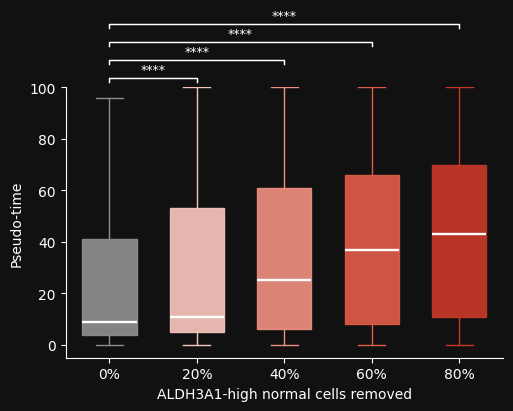

In [2]:
from scipy.stats import mannwhitneyu
FRACTIONS = (0, 20, 40, 60, 80)
COLORS = {0: "#8f8f8f", 20: "#f7c5bd", 40: "#ee8f80", 60: "#df5c49", 80: "#c73827"}
def save(fig, stem):
    finish(fig, stem.stem)

def draw_group_boxplot(data: pd.DataFrame, clusters: tuple[str, ...], label: str) -> None:
    subset = data[data.cluster.astype(str).isin(clusters)].copy()
    values = [subset.loc[subset.fraction_percent.eq(f), "time"].to_numpy() for f in FRACTIONS]
    fig, ax = plt.subplots(figsize=(5.4, 5.2))
    bp = ax.boxplot(values, positions=np.arange(len(FRACTIONS)), widths=0.62,
                    patch_artist=True, showfliers=False,
                    medianprops={"color": "white", "linewidth": 1.7})
    for index, fraction in enumerate(FRACTIONS):
        color = COLORS[fraction]
        bp["boxes"][index].set(facecolor=color, edgecolor=color, alpha=0.92)
        for artist in (bp["whiskers"][2*index], bp["whiskers"][2*index+1],
                       bp["caps"][2*index], bp["caps"][2*index+1]):
            artist.set_color(color)
    baseline = values[0]
    stats = []
    ymax = max(float(np.max(x)) for x in values if len(x))
    ymin = min(float(np.min(x)) for x in values if len(x))
    span = max(ymax - ymin, 1.0)
    # Keep the data axis fixed at 0--100, while drawing significance brackets
    # in reserved whitespace above the axes so they never cover the boxes.
    base_y = 102.0
    step = 7.0
    hook = 1.6

    def stars(p: float) -> str:
        if p < 1e-4:
            return "****"
        if p < 1e-3:
            return "***"
        if p < 1e-2:
            return "**"
        if p < 0.05:
            return "*"
        return "ns"

    for level, (index, fraction) in enumerate(zip(range(1, len(FRACTIONS)), FRACTIONS[1:])):
        # One-sided test matching the notebook hypothesis: perturbed pseudo-time
        # is greater (delayed) relative to the fixed unperturbed rollout.
        statistic, pvalue = mannwhitneyu(baseline, values[index], alternative="less")
        y = base_y + level * step
        ax.plot([0, 0, index, index], [y, y + hook, y + hook, y],
                color="white", linewidth=1.05, clip_on=False)
        ax.text(index / 2, y + hook + 0.7, stars(float(pvalue)),
                color="white", ha="center", va="bottom", fontsize=9,
                clip_on=False)
        stats.append({
            "group": label.lower(), "clusters": "/".join(clusters),
            "reference_fraction_percent": 0,
            "comparison_fraction_percent": fraction,
            "alternative": "comparison_greater_than_0_percent",
            "mannwhitney_u": statistic, "pvalue": pvalue,
            "significance": stars(float(pvalue)),
            "n_reference": len(baseline), "n_comparison": len(values[index]),
        })
    ax.set_ylim(-5, 100)
    ax.set_xticks(np.arange(len(FRACTIONS)), [f"{f}%" for f in FRACTIONS])
    ax.set_xlabel("ALDH3A1-high normal cells removed")
    ax.set_ylabel("Pseudo-time")
    style_axis(ax)
    fig.subplots_adjust(left=0.17, right=0.98, bottom=0.16, top=0.68)
    save(fig, OUTPUT / f"{label.lower()}_clusters_pseudotime_boxplot")

data = pd.read_csv(DATA / "normal_clusters_boxplot_data.csv")
assert set(data.cluster.astype(str).unique()) == {"8", "12"}
draw_group_boxplot(data, ("8", "12"), "Normal")